## **Machine Learning Aplicado a las Finanzas** 🚀
### **Sesión 12: Deep Learning TS — Redes para Series Financieras**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 🚀 **`Motivación: De Features Tabulares a Secuencias`**

### Lo que ya sabemos (Sesiones 8-11)

Hasta ahora tratamos el tiempo **indirectamente**: Random Forest y Gradient Boosting (Sesiones 8-9) consumen $x_t = (r_{t-1}, r_{t-2}, \dots, r_{t-k}, \text{features de calendario}, \dots)$ como un vector plano. El modelo no "sabe" que $r_{t-1}$ ocurrió después de $r_{t-2}$ — solo ve columnas.

Esto funciona razonablemente bien y es difícil de vencer en finanzas (señal-ruido bajo, datos tabulares moderados). Pero tiene un costo:

- El orden y la distancia temporal entre observaciones se pierden; el modelo no comparte pesos a través del tiempo.
- Capturar dependencias de **largo plazo** requiere agregar manualmente más lags o features de ventana (rolling mean, rolling std), lo cual es ingeniería de features, no aprendizaje.

### Qué prometen las redes secuenciales

Una red recurrente (RNN/LSTM/GRU) o convolucional causal (TCN) recibe la secuencia $\{x_1, \dots, x_T\}$ como tal y aprende una representación del estado que se actualiza paso a paso. La promesa:

$$h_t = f_\theta(x_t, h_{t-1})$$

El mismo $f_\theta$ se reutiliza en cada paso temporal (weight sharing), lo que en teoría permite capturar patrones de duración variable sin explotar el número de parámetros.

**El costo:** más datos requeridos, entrenamiento más caro, e interpretabilidad mucho más difícil que SHAP sobre un GBM (Sesión 10). En este curso, la pregunta que nos interesa **no es** "¿son las redes mejores?", sino **"¿bajo qué condiciones justifican su costo frente a boosting?"** — eso es lo que vamos a medir al final de la clase.

## 📈 **`Dataset Real: SPY vía yfinance`**

A diferencia de los ejercicios de las sesiones previas donde a veces controlamos el generador con datos sintéticos, aquí usamos **datos de mercado reales** — mismo criterio que la Sesión 10 — para que la comparación entre arquitecturas y contra boosting sea sobre el problema real: señal-ruido bajo, no estacionariedad, régimen cambiante, sin verdad generadora conocida.

Usamos `SPY` (ETF del S&P 500) diario, 2005–2024. Es un activo largo y líquido, lo que nos da ~19 años de historia para que las redes tengan datos suficientes — algo que **no** es trivial de conseguir con una sola serie financiera univariada, y es justamente una de las limitaciones que discutimos en la motivación.

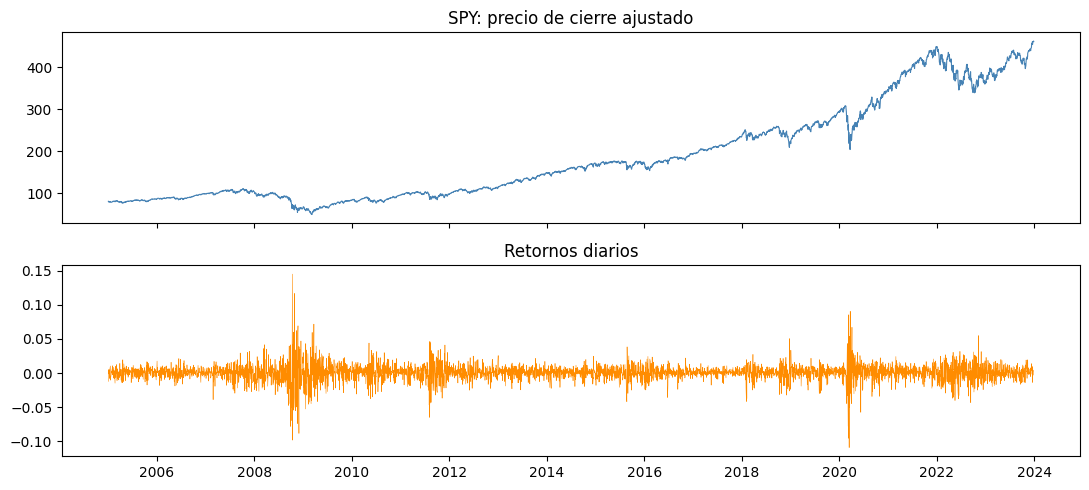

In [2]:
TICKER = "SPY"

raw = yf.download(TICKER, start="2005-01-01", end="2024-01-01", progress=False, auto_adjust=True)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

close = raw["Close"]
ret = close.pct_change()

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(close.index, close, color="steelblue", lw=0.8)
axes[0].set_title(f"{TICKER}: precio de cierre ajustado")
axes[1].plot(ret.index, ret, color="darkorange", lw=0.4)
axes[1].set_title("Retornos diarios")
plt.tight_layout()
plt.show()

## 🧱 **`Ventaneo sin Leakage: de Serie a Tensor (samples, timesteps, features)`**

Igual que en la Sesión 3, la regla es: **toda transformación (escalado, normalización, indicadores) se calcula solo con información hasta $t-1$**, y el escalador se ajusta **solo con el split de entrenamiento** — para deep learning esto es aún más crítico que para árboles, porque las redes son mucho más sensibles a la escala de entrada.

Construimos un set de features de mercado (retornos, volatilidad realizada, momentum, RSI — el mismo tipo de indicadores que en la Sesión 10) y ventanas deslizantes de tamaño $L$ (lookback) para predecir el retorno en $t+1$:

$$X_i = (x_{t-L+1}, \dots, x_t) \in \mathbb{R}^{L \times F}, \qquad y_i = r_{t+1}$$

In [3]:
def make_features(raw):
    close = raw["Close"]
    ret = close.pct_change()

    out = pd.DataFrame(index=raw.index)
    out["ret"] = ret
    out["ret_lag1"] = ret.shift(1)
    out["roll_std_5"] = ret.rolling(5).std()
    out["roll_std_20"] = ret.rolling(20).std()
    out["mom_10"] = close.shift(1) / close.shift(11) - 1

    delta = close.diff()
    gain = delta.clip(lower=0).shift(1).rolling(14).mean()
    loss = (-delta.clip(upper=0)).shift(1).rolling(14).mean()
    out["rsi_14"] = 100 - 100 / (1 + gain / loss.replace(0, np.nan))
    out["vol_chg"] = raw["Volume"].pct_change().shift(1)

    return out.dropna()

feat_cols = ["ret", "roll_std_5", "roll_std_20", "mom_10", "rsi_14", "vol_chg"]
data = make_features(raw)

def windowize(arr_x, arr_y, L):
    Xs, ys = [], []
    for t in range(L, len(arr_x)):
        Xs.append(arr_x[t - L:t])
        ys.append(arr_y[t])
    return np.array(Xs), np.array(ys)

L = 20
X_raw = data[feat_cols].values
y_raw = data["ret"].shift(-1).values  # target: retorno del día siguiente

# quitamos la última fila (target NaN por el shift)
X_raw, y_raw = X_raw[:-1], y_raw[:-1]

n = len(X_raw)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

# el scaler se ajusta SOLO con train (misma disciplina que Sesión 3)
scaler = StandardScaler().fit(X_raw[:n_train])
X_scaled = scaler.transform(X_raw)

X_win, y_win = windowize(X_scaled, y_raw, L)

# offset de L: las ventanas empiezan L pasos después
split_train = n_train - L
split_val = n_train + n_val - L

X_train, y_train = X_win[:split_train], y_win[:split_train]
X_val, y_val = X_win[split_train:split_val], y_win[split_train:split_val]
X_test, y_test = X_win[split_val:], y_win[split_val:]

print(f"train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")

train=(3311, 20, 6), val=(713, 20, 6), test=(715, 20, 6)


In [4]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH = 64
train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=BATCH, shuffle=True)
val_loader = DataLoader(SeqDataset(X_val, y_val), batch_size=BATCH, shuffle=False)
test_loader = DataLoader(SeqDataset(X_test, y_test), batch_size=BATCH, shuffle=False)

## ⚙️ **`El Proceso de Optimización: BPTT + Adam + Gradient Clipping`**

Todas las arquitecturas que siguen (MLP, RNN, LSTM, GRU, TCN) se entrenan con el mismo procedimiento genérico de descenso de gradiente estocástico. Vale la pena hacerlo explícito antes de ver cada arquitectura, porque **la arquitectura define $f_\theta$, pero es el optimizador el que efectivamente encuentra $\theta$.**

**1. Backpropagation Through Time (BPTT).** Para las redes recurrentes, cada ventana de largo $L=20$ se "despliega" en $L$ copias de la misma celda con parámetros compartidos. El forward pass calcula $h_1, h_2, \dots, h_L$ secuencialmente; el backward pass acumula $\partial \mathcal{L} / \partial \theta$ sumando la contribución de cada paso temporal — por eso decimos que la red comparte pesos *a través del tiempo* y no solo a través de ejemplos del batch. Como $L=20$ es corto, hacemos BPTT completo (sin truncar); en secuencias de miles de pasos se trunca la ventana de gradiente por costo de memoria.

**2. Adam.** Usamos Adam en vez de SGD plano porque adapta la tasa de aprendizaje por parámetro usando momentos de primer y segundo orden del gradiente:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\hat m_t = \frac{m_t}{1-\beta_1^t}, \qquad \hat v_t = \frac{v_t}{1-\beta_2^t}, \qquad \theta_t = \theta_{t-1} - \eta \frac{\hat m_t}{\sqrt{\hat v_t} + \epsilon}$$

Esto importa especialmente para RNN/LSTM/GRU: distintos parámetros (compuertas vs pesos de salida) tienen gradientes de magnitud muy distinta, y Adam normaliza ese desbalance automáticamente — con SGD plano el tuning de $\eta$ es mucho más sensible.

**3. Gradient clipping.** Incluso con LSTM/GRU, el gradiente puede explotar ocasionalmente (batches con retornos extremos, ej. crashes). Recortamos la norma global del gradiente antes de cada paso:

$$g \leftarrow g \cdot \min\left(1, \frac{\text{clip\_norm}}{\|g\|_2}\right)$$

Esto no evita el vanishing gradient (para eso están las compuertas), pero sí evita que un solo batch "vuele" los pesos y desestabilice el entrenamiento — es una práctica estándar en RNN, no opcional.

**4. Early stopping sobre validación.** Como en boosting (Sesión 9), monitoreamos la pérdida de validación y nos quedamos con los pesos del mejor epoch, no los del último — la red sigue bajando el error de entrenamiento después del punto óptimo de generalización (overfitting), y con series financieras ruidosas esto ocurre rápido.

In [5]:
def train_model(model, train_loader, val_loader, epochs=60, lr=1e-3, patience=8,
                 clip_norm=1.0, verbose=False):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val = np.inf
    best_state = None
    wait = 0
    history = {"train": [], "val": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)  # evita gradientes explosivos
            opt.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += loss_fn(model(xb), yb).item() * len(xb)
        val_loss /= len(val_loader.dataset)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping en epoch {epoch}")
                break

        if verbose and epoch % 10 == 0:
            print(f"epoch {epoch:3d} | train {train_loss:.6f} | val {val_loss:.6f}")

    model.load_state_dict(best_state)
    return model, history

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        preds.append(model(xb).cpu().numpy())
        trues.append(yb.numpy())
    preds = np.concatenate(preds).ravel()
    trues = np.concatenate(trues).ravel()
    return preds, trues, {
        "mse": mean_squared_error(trues, preds),
        "mae": mean_absolute_error(trues, preds),
    }

## ⚪ **`Baseline: MLP sobre la ventana aplanada`**

Antes de justificar RNN/LSTM/GRU/TCN, necesitamos un baseline honesto: un MLP que recibe la ventana **aplanada** ($L \times F \to L \cdot F$), sin ninguna estructura secuencial. Si las arquitecturas secuenciales no superan esto de forma consistente, su costo adicional no se justifica.

**Arquitectura (flujo de la información):**

!['arquitectura MLP'](MLP.png)

Cada capa `Linear` es una transformación afín $z = Wx + b$ seguida de una no linealidad; el `Dropout` apaga aleatoriamente el 20% de las activaciones durante entrenamiento para evitar que la red memorice combinaciones específicas de ruido — el análogo, en deep learning, del `subsample` de Gradient Boosting (Sesión 9). Como al aplanar la ventana se pierde la posición temporal explícita, el MLP debe inferir el orden únicamente de la posición de cada valor en el vector — no la aprovecha estructuralmente, a diferencia de las arquitecturas que siguen.

In [6]:
class MLPBaseline(nn.Module):
    def __init__(self, L, F_in, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(L * F_in, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        return self.net(x)

mlp = MLPBaseline(L=L, F_in=len(feat_cols))
mlp, hist_mlp = train_model(mlp, train_loader, val_loader, verbose=True)
_, _, metrics_mlp = evaluate(mlp, test_loader)
metrics_mlp

epoch   0 | train 0.001878 | val 0.000861


epoch  10 | train 0.000132 | val 0.000274


epoch  20 | train 0.000113 | val 0.000247
Early stopping en epoch 22


{'mse': 0.000132381625007838, 'mae': 0.008662971667945385}

## 🔁 **`RNN Vanilla: la Idea y su Límite`**

Una RNN simple actualiza un estado oculto con:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$

Al hacer backpropagation through time (BPTT), el gradiente respecto a $h_0$ involucra un producto de $T$ jacobianos:

$$\frac{\partial h_T}{\partial h_0} = \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}}$$

Si los autovalores de esos jacobianos son sistemáticamente $<1$, el producto **se desvanece** exponencialmente (vanishing gradient); si son $>1$, **explota**. En series financieras con memoria de régimen (rachas de alta/baja volatilidad que persisten semanas), esto es letal: la RNN vanilla no logra "recordar" información de hace 15-20 pasos, exactamente el rango de $L$ que estamos usando.

**Arquitectura (flujo temporal, un paso $t$):**

!['arquitectura RNN'](RNN.png)

El mismo bloque `[tanh(...)]` se reutiliza en cada paso (weight sharing) — por eso el número de parámetros no crece con $L$. Solo usamos el estado final $h_L$ para la predicción, ya que resume (en teoría) toda la ventana.

LSTM y GRU resuelven el vanishing gradient con **compuertas** (gates) que permiten que el gradiente fluya por un camino aditivo, no puramente multiplicativo.

In [7]:
class RNNRegressor(nn.Module):
    def __init__(self, F_in, hidden=32, cell="rnn", num_layers=1, dropout=0.0):
        super().__init__()
        cell_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell]
        self.rnn = cell_cls(F_in, hidden, num_layers=num_layers, batch_first=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(hidden, 1))

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]          # estado oculto final
        return self.head(last)

rnn_vanilla = RNNRegressor(F_in=len(feat_cols), hidden=32, cell="rnn")
rnn_vanilla, hist_rnn = train_model(rnn_vanilla, train_loader, val_loader, verbose=True)
_, _, metrics_rnn = evaluate(rnn_vanilla, test_loader)
metrics_rnn

epoch   0 | train 0.009062 | val 0.000888


epoch  10 | train 0.000331 | val 0.000215


Early stopping en epoch 18


{'mse': 0.00013533544552046806, 'mae': 0.008892744779586792}

## 🔒 **`LSTM y GRU: Compuertas para Memoria de Largo Plazo`**

**LSTM** mantiene un estado de celda $c_t$ separado del estado oculto $h_t$, controlado por tres compuertas (forget, input, output):

$$f_t = \sigma(W_f[h_{t-1}, x_t]), \quad i_t = \sigma(W_i[h_{t-1}, x_t]), \quad o_t = \sigma(W_o[h_{t-1}, x_t])$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t, \qquad h_t = o_t \odot \tanh(c_t)$$

El camino $c_{t-1} \to c_t$ es **aditivo** (suma ponderada por $f_t$), lo que evita el colapso multiplicativo del gradiente. En términos de flujo:

```
             ┌──── f_t ────┐   (forget: qué olvidar de c_{t-1})
c_{t-1} ─────┤             ├──> c_t = f_t⊙c_{t-1} + i_t⊙c̃_t ──┐
             └──── i_t ────┘   (input: qué escribir de nuevo)  │
x_t, h_{t-1} ───────────────────────────────────────────────────┤
                                                                  ▼
                                            h_t = o_t ⊙ tanh(c_t)   (output: qué exponer)
```

**GRU** simplifica esto a dos compuertas (reset $r_t$, update $z_t$) y fusiona $h_t$ y $c_t$ en un solo estado:

$$z_t = \sigma(W_z[h_{t-1}, x_t]), \quad r_t = \sigma(W_r[h_{t-1}, x_t])$$
$$\tilde h_t = \tanh(W[r_t \odot h_{t-1}, x_t]), \qquad h_t = (1-z_t)\odot h_{t-1} + z_t \odot \tilde h_t$$

Menos parámetros, entrenamiento más rápido, y en la práctica desempeño muy similar a LSTM en series cortas/medianas como las financieras.

| | Parámetros por capa | Estados | Cuándo preferir |
|---|---|---|---|
| LSTM | $4(F \cdot H + H^2 + H)$ | $h_t, c_t$ | series largas, memoria muy fina |
| GRU | $3(F \cdot H + H^2 + H)$ | $h_t$ | datasets chicos, iterar rápido |

In [8]:
lstm = RNNRegressor(F_in=len(feat_cols), hidden=32, cell="lstm")
lstm, hist_lstm = train_model(lstm, train_loader, val_loader, verbose=True)
_, _, metrics_lstm = evaluate(lstm, test_loader)

gru = RNNRegressor(F_in=len(feat_cols), hidden=32, cell="gru")
gru, hist_gru = train_model(gru, train_loader, val_loader, verbose=True)
_, _, metrics_gru = evaluate(gru, test_loader)

pd.DataFrame({"RNN": metrics_rnn, "LSTM": metrics_lstm, "GRU": metrics_gru}).T

epoch   0 | train 0.004359 | val 0.000418


epoch  10 | train 0.000271 | val 0.000222


epoch  20 | train 0.000181 | val 0.000217


Early stopping en epoch 28
epoch   0 | train 0.006379 | val 0.000545


epoch  10 | train 0.000280 | val 0.000240


epoch  20 | train 0.000164 | val 0.000221


epoch  30 | train 0.000151 | val 0.000234


Early stopping en epoch 34


,mse,mae
RNN,0.000135,0.008893
LSTM,0.000123,0.008229
GRU,0.000126,0.008405


## 🧩 **`Temporal Convolutional Network (TCN): Arquitectura Completa`**

Las TCN reemplazan la recurrencia por **convoluciones causales y dilatadas**, apiladas en bloques residuales. Tres ingredientes:

**1. Convolución causal:** la salida en $t$ solo depende de $x_{\le t}$ — nunca del futuro (padding a la izquierda). Esto es lo que hace la TCN comparable a una RNN para forecasting (a diferencia de una CNN 1D estándar, que ve ambos lados).

**2. Dilatación exponencial:** la capa $k$ usa dilatación $d = 2^k$, de forma que el **campo receptivo** crece exponencialmente con la profundidad en vez de linealmente:

$$\text{receptive field} = 1 + 2 (k_{\text{size}} - 1) \sum_{i=0}^{K-1} 2^i$$

Con esto, pocas capas alcanzan un lookback largo sin sacrificar paralelización (a diferencia de una RNN, que es intrínsecamente secuencial).

**3. Conexiones residuales:** cada bloque suma su entrada a su salida (con una conv 1x1 si cambian los canales), lo que permite apilar muchas capas sin degradar el entrenamiento — la misma idea de ResNet.

**Arquitectura de un `TemporalBlock`:**

```
x ──> Conv1d(dilation=d) ──> Chomp ──> ReLU ──> Dropout ──>
      Conv1d(dilation=d) ──> Chomp ──> ReLU ──> Dropout ──> out
│                                                              │
└──────────────── downsample (conv 1x1, si cambia n_canales) ─┴──> ReLU(out + residual)
```

`Chomp1d` recorta el padding sobrante a la derecha que produce el padding causal, para que la salida tenga el mismo largo temporal que la entrada sin filtrar información del futuro. La red completa apila $K$ bloques con dilatación $d=2^0, 2^1, \dots, 2^{K-1}$ — cada nivel "ve" hacia atrás el doble de lejos que el anterior con el mismo costo de una capa.

**Por qué importa en finanzas:** el entrenamiento de una TCN es **paralelizable en el eje temporal** (todas las posiciones de la secuencia se computan a la vez), mientras que una RNN debe procesar paso a paso. En walk-forward con reentrenamientos frecuentes (Sesión 3), esto es una ventaja práctica considerable.

In [9]:
class Chomp1d(nn.Module):
    # recorta el padding residual a la derecha para mantener causalidad
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, n_in, n_out, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation  # padding causal

        self.conv1 = nn.utils.weight_norm(
            nn.Conv1d(n_in, n_out, kernel_size, padding=padding, dilation=dilation))
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.utils.weight_norm(
            nn.Conv1d(n_out, n_out, kernel_size, padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.drop1,
                                  self.conv2, self.chomp2, self.relu2, self.drop2)

        self.downsample = nn.Conv1d(n_in, n_out, 1) if n_in != n_out else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCN(nn.Module):
    def __init__(self, F_in, channels=(32, 32, 32), kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        n_levels = len(channels)
        for i in range(n_levels):
            dilation = 2 ** i
            in_ch = F_in if i == 0 else channels[i - 1]
            out_ch = channels[i]
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout))
        self.tcn = nn.Sequential(*layers)
        self.head = nn.Linear(channels[-1], 1)

        # campo receptivo, informativo para elegir L
        self.receptive_field = 1 + 2 * (kernel_size - 1) * sum(2 ** i for i in range(n_levels))

    def forward(self, x):
        # x: (batch, timesteps, features) -> Conv1d espera (batch, features, timesteps)
        x = x.transpose(1, 2)
        out = self.tcn(x)
        last = out[:, :, -1]
        return self.head(last)


tcn = TCN(F_in=len(feat_cols), channels=(32, 32, 32), kernel_size=3, dropout=0.2)
print(f"Campo receptivo de la TCN: {tcn.receptive_field} pasos (lookback usado: L={L})")
tcn, hist_tcn = train_model(tcn, train_loader, val_loader, verbose=True)
_, _, metrics_tcn = evaluate(tcn, test_loader)
metrics_tcn

Campo receptivo de la TCN: 29 pasos (lookback usado: L=20)


epoch   0 | train 0.019731 | val 0.006269


epoch  10 | train 0.000672 | val 0.001130


epoch  20 | train 0.000301 | val 0.000621


epoch  30 | train 0.000190 | val 0.000453


epoch  40 | train 0.000167 | val 0.000358


epoch  50 | train 0.000133 | val 0.000341


{'mse': 0.00017068846500478685, 'mae': 0.009882833808660507}

In [10]:
results = pd.DataFrame({
    "MLP": metrics_mlp,
    "RNN": metrics_rnn,
    "LSTM": metrics_lstm,
    "GRU": metrics_gru,
    "TCN": metrics_tcn,
}).T.sort_values("mse")

results

,mse,mae
LSTM,0.000123,0.008229
GRU,0.000126,0.008405
MLP,0.000132,0.008663
RNN,0.000135,0.008893
TCN,0.000171,0.009883


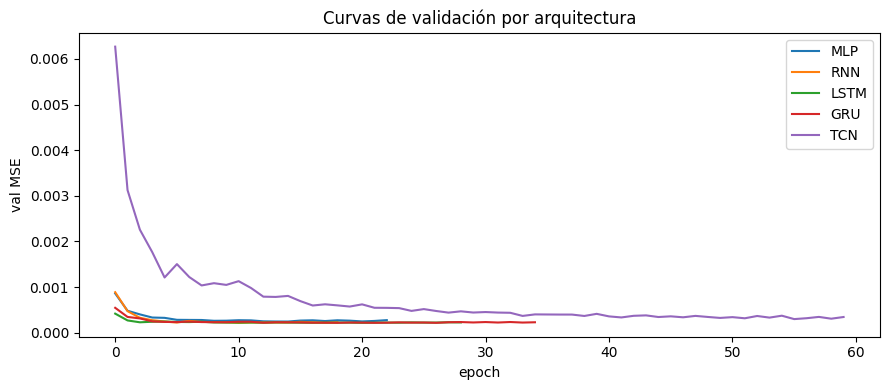

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
for name, hist in [("MLP", hist_mlp), ("RNN", hist_rnn), ("LSTM", hist_lstm),
                    ("GRU", hist_gru), ("TCN", hist_tcn)]:
    ax.plot(hist["val"], label=name)
ax.set_xlabel("epoch")
ax.set_ylabel("val MSE")
ax.set_title("Curvas de validación por arquitectura")
ax.legend()
plt.tight_layout()
plt.show()

## ⚖️ **`Comparación Crítica: Deep Learning vs Boosting (Sesión 9)`**

Entrenamos ahora un `GradientBoostingRegressor` sobre **la misma ventana aplanada** que usó el MLP, con la misma partición train/val/test (sin leakage), para que la comparación sea justa.

In [12]:
from sklearn.ensemble import GradientBoostingRegressor

X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

gbr = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                 subsample=0.8, random_state=SEED)
gbr.fit(X_train_flat, y_train)
pred_gbr = gbr.predict(X_test_flat)

metrics_gbr = {
    "mse": mean_squared_error(y_test, pred_gbr),
    "mae": mean_absolute_error(y_test, pred_gbr),
}

results.loc["GBM"] = metrics_gbr
results.sort_values("mse")

,mse,mae
LSTM,0.000123,0.008229
GRU,0.000126,0.008405
GBM,0.000130,0.008464
MLP,0.000132,0.008663
RNN,0.000135,0.008893
TCN,0.000171,0.009883


### Lectura de resultados

En un problema de retornos diarios de un solo activo — señal-ruido bajísimo, no estacionario, y con solo unos pocos miles de observaciones incluso usando ~19 años de historia — es común observar que:

- El **GBM** iguala o supera a las redes secuenciales, porque necesita muchos menos datos para generalizar y su regularización (profundidad, subsampling) es más fácil de tunear que la de una red.
- **LSTM/GRU/TCN** tienden a acercarse o superar al GBM cuando (a) el dataset es mucho más grande (miles de series, no una sola), (b) las dependencias temporales son más largas de lo que unos pocos lags pueden capturar, o (c) se combinan múltiples series correlacionadas (panel, no una sola serie univariada) — ahí el weight sharing temporal empieza a pagar su costo de complejidad.
- Entre las redes, **TCN suele entrenar más rápido y de forma más estable** que RNN/LSTM/GRU para el mismo largo de secuencia, gracias a la paralelización — relevante si el pipeline de producción requiere reentrenos frecuentes (walk-forward, Sesión 3).

**Conclusión operativa para el curso:** deep learning secuencial no es un reemplazo por defecto de boosting en datos financieros tabulares/univariados; es una herramienta a evaluar cuando el volumen de datos y la naturaleza del problema (panel grande, dependencias largas, múltiples activos) lo justifican — y ese trade-off debe documentarse explícitamente en el model risk report (Sesión 10).

## 🔍 **`Nota: Interpretabilidad en Redes Secuenciales`**

SHAP (Sesión 10) se puede aplicar a redes con `DeepExplainer` o `GradientExplainer`, pero:

- El costo computacional crece con el largo de secuencia y el número de parámetros.
- La atribución por timestep es más ruidosa que la atribución por feature en un GBM, porque hay colinealidad temporal fuerte (el retorno de ayer y el rolling std de 5 días comparten información).

Alternativas más económicas y ya usadas en la industria:
- **Gradientes de entrada** (`saliency`): $\partial \hat y / \partial x_t$, barato pero ruidoso.
- **Mecanismos de atención** (si se agrega una capa de atención sobre la salida de la LSTM/TCN): los pesos de atención dan una lectura directa de qué timesteps pesaron más — no es una prueba causal, pero es más barato que SHAP y más interpretable que un gradiente crudo.

Para producción, la recomendación práctica es: si la interpretabilidad es un requisito regulatorio duro (crédito, Sesión 11), preferir GBM + SHAP; reservar deep learning secuencial para tareas donde la interpretabilidad es secundaria frente a la ganancia de performance.

## 📌 **`Cierre`**

**Qué vimos:**
- Por qué y cuándo secuenciar los datos (RNN/LSTM/GRU/TCN) puede aportar sobre un enfoque tabular (MLP, GBM).
- El proceso de optimización que entrena a todas estas arquitecturas: BPTT, Adam, gradient clipping, early stopping.
- Vanishing gradient en RNN vanilla y cómo LSTM/GRU lo resuelven con compuertas.
- TCN completa: convolución causal, dilatación exponencial, bloques residuales, campo receptivo.
- Comparación empírica y honesta, sobre datos reales de mercado (SPY), contra el baseline de boosting de la Sesión 9.
- Limitaciones de interpretabilidad de las redes secuenciales frente a SHAP sobre GBM (Sesión 10).

Con esto se cierra el contenido del curso: el pipeline completo —desde validación walk-forward (Sesión 3) hasta deep learning secuencial— queda cubierto de principio a fin.